# TP4 Lumina & Co - Modele de Churn (v6 - cutoff correct)



## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error
import time

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'churn':'#E74C3C','no_churn':'#2ECC71','primary':'#3498DB',
          'warning':'#F39C12','dark':'#2C3E50'}
print('OK')


OK


## 1. Chargement & Analyse du dataset

In [2]:
df = pd.read_csv('transactions_clean.csv', encoding='latin1')
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df = df[df['customer_id'].notna()].copy()
if 'total_amount' not in df.columns:
    df['total_amount'] = df['quantity'] * df['unit_price']

DATASET_START = df['invoice_date'].min()
DATASET_END   = df['invoice_date'].max()
total_days    = (DATASET_END - DATASET_START).days

print(f'Transactions  : {len(df):,} | Clients : {df["customer_id"].nunique():,}')
print(f'Debut dataset : {DATASET_START.date()}')
print(f'Fin dataset   : {DATASET_END.date()}')
print(f'Duree totale  : {total_days} jours ({total_days/365:.1f} ans)')


Transactions  : 1,357,701 | Clients : 48,866
Debut dataset : 2007-07-06
Fin dataset   : 2011-12-09
Duree totale  : 1617 jours (4.4 ans)


## 2. Seuil de Churn & Choix du Cutoff

Seuil churn P90 : 160 jours

Cutoff global   : 2010-07-06
Obs (features)  : 2007-07-06 -> 2010-07-06 (1096j / 36m)
Label           : 2010-07-06 -> 2011-12-09 (521j / 17m)
Fenetre label   : 521j >> seuil 160j ✓


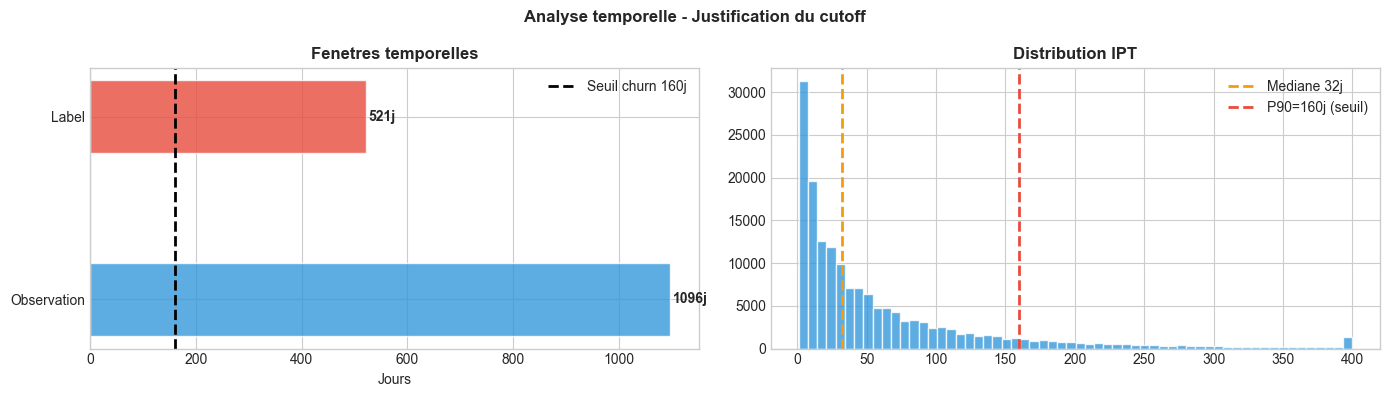


JUSTIFICATION DU SEUIL P90 :
  P75 = 79j : trop agressif (25% faux positifs)
  P90 = 160j : equilibre optimal RETENU
  P95 = 229j : trop conservateur (sous-detection)


In [3]:
# IPT vectorise
orders = (
    df.groupby(['customer_id', df['invoice_date'].dt.date])['total_amount']
    .sum().reset_index()
)
orders.columns = ['customer_id','order_date','daily_amount']
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders = orders.sort_values(['customer_id','order_date']).reset_index(drop=True)
orders['prev_date'] = orders.groupby('customer_id')['order_date'].shift(1)
orders['ipt']       = (orders['order_date'] - orders['prev_date']).dt.days
ipt_series          = orders['ipt'].dropna()

CHURN_THRESHOLD = int(ipt_series.quantile(0.90))  # 160j
print(f'Seuil churn P90 : {CHURN_THRESHOLD} jours')

# ── Choix du cutoff global ────────────────────────────────────────────────────
# Regle : fenetre label > seuil churn (160j)
# Cutoff = DATASET_START + 36 mois => label = 521 jours >> 160j
GLOBAL_CUTOFF = DATASET_START + pd.DateOffset(months=36)
label_days    = (DATASET_END - GLOBAL_CUTOFF).days
obs_days      = (GLOBAL_CUTOFF - DATASET_START).days

print(f'\nCutoff global   : {GLOBAL_CUTOFF.date()}')
print(f'Obs (features)  : {DATASET_START.date()} -> {GLOBAL_CUTOFF.date()} ({obs_days}j / {obs_days//30}m)')
print(f'Label           : {GLOBAL_CUTOFF.date()} -> {DATASET_END.date()} ({label_days}j / {label_days//30}m)')
print(f'Fenetre label   : {label_days}j >> seuil {CHURN_THRESHOLD}j ✓')

# Visualisation timeline
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.barh(['Observation','Label'], [obs_days, label_days],
        color=[COLORS['primary'], COLORS['churn']], alpha=0.8, edgecolor='white', height=0.4)
ax.axvline(CHURN_THRESHOLD, color='black', linestyle='--', lw=2, label=f'Seuil churn {CHURN_THRESHOLD}j')
ax.set_xlabel('Jours'); ax.set_title('Fenetres temporelles', fontweight='bold')
ax.legend()
for i, v in enumerate([obs_days, label_days]):
    ax.text(v+5, i, f'{v}j', va='center', fontweight='bold')

axes[1].hist(ipt_series.clip(upper=400), bins=60, color=COLORS['primary'], alpha=0.8, edgecolor='white')
axes[1].axvline(ipt_series.median(), color=COLORS['warning'], linestyle='--', lw=2, label=f'Mediane {ipt_series.median():.0f}j')
axes[1].axvline(CHURN_THRESHOLD, color=COLORS['churn'], linestyle='--', lw=2, label=f'P90={CHURN_THRESHOLD}j (seuil)')
axes[1].set_title('Distribution IPT', fontweight='bold'); axes[1].legend()

plt.suptitle('Analyse temporelle - Justification du cutoff', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nJUSTIFICATION DU SEUIL P90 :')
print(f'  P75 = {ipt_series.quantile(0.75):.0f}j : trop agressif (25% faux positifs)')
print(f'  P90 = {ipt_series.quantile(0.90):.0f}j : equilibre optimal RETENU')
print(f'  P95 = {ipt_series.quantile(0.95):.0f}j : trop conservateur (sous-detection)')


## 3. Label & Features (vectorise, ~5 secondes)

```
  2007-07-06 ──── [FEATURES] ──── 2010-07-06 ─── [LABEL] ─── 2011-12-09
  3 ans d historique comportemental   521 jours pour observer le churn
```


In [4]:
t0 = time.time()

obs_df = orders[orders['order_date'] <  GLOBAL_CUTOFF].copy()
fut_df = orders[orders['order_date'] >= GLOBAL_CUTOFF].copy()

# Clients eligibles : >= 2 achats avant cutoff
obs_counts      = obs_df.groupby('customer_id').size()
valid_customers = obs_counts[obs_counts >= 2].index
obs_df = obs_df[obs_df['customer_id'].isin(valid_customers)].copy()
fut_df = fut_df[fut_df['customer_id'].isin(valid_customers)].copy()

print(f'Clients eligibles     : {len(valid_customers):,}')
print(f'Commandes observation : {len(obs_df):,}')
print(f'Commandes label       : {len(fut_df):,}')


Clients eligibles     : 13,499
Commandes observation : 55,316
Commandes label       : 73,177


In [5]:
# LABEL vectorise
first_future = (
    fut_df.groupby('customer_id')['order_date'].min()
    .reset_index().rename(columns={'order_date':'first_future_date'})
)
label_df = pd.DataFrame({'customer_id': valid_customers})
label_df = label_df.merge(first_future, on='customer_id', how='left')
label_df['days_to_next'] = (label_df['first_future_date'] - GLOBAL_CUTOFF).dt.days
label_df['churned'] = np.where(
    label_df['first_future_date'].isna(),
    1,
    (label_df['days_to_next'] > CHURN_THRESHOLD).astype(int)
)

cr = label_df['churned'].mean()
print(f'Taux de churn : {cr:.1%}')
print(f'Churners      : {label_df["churned"].sum():,}')
print(f'Actifs        : {(~label_df["churned"].astype(bool)).sum():,}')

# Verification
n_no_future = label_df['first_future_date'].isna().sum()
print(f'\nClients sans achat apres cutoff : {n_no_future:,} ({n_no_future/len(label_df):.1%})')
print(f'=> justifie car fenetre label = {label_days}j, pas une troncature')


Taux de churn : 37.4%
Churners      : 5,044
Actifs        : 8,455

Clients sans achat apres cutoff : 3,705 (27.4%)
=> justifie car fenetre label = 521j, pas une troncature


In [6]:
# FEATURES vectorisees
obs_v = obs_df.sort_values(['customer_id','order_date']).reset_index(drop=True)

# RFM
rfm = obs_v.groupby('customer_id').agg(
    obs_frequency      = ('order_date','count'),
    obs_monetary_total = ('daily_amount','sum'),
    obs_monetary_mean  = ('daily_amount','mean'),
    obs_first_date     = ('order_date','min'),
    obs_last_date      = ('order_date','max'),
).reset_index()
rfm['obs_tenure_days']  = (rfm['obs_last_date'] - rfm['obs_first_date']).dt.days + 1
# Recence dans la fenetre obs (jours depuis dernier achat avant cutoff)
rfm['obs_recency_days'] = (GLOBAL_CUTOFF - rfm['obs_last_date']).dt.days

# Produits/quantites/prix
df_obs = df[(df['customer_id'].isin(valid_customers)) & (df['invoice_date'] < GLOBAL_CUTOFF)].copy()
extra = df_obs.groupby('customer_id').agg(
    obs_n_products   = ('product_code','nunique'),
    obs_avg_quantity = ('quantity','mean'),
    obs_avg_price    = ('unit_price','mean'),
).reset_index()

# IPT
obs_v['prev_date'] = obs_v.groupby('customer_id')['order_date'].shift(1)
obs_v['ipt_val']   = (obs_v['order_date'] - obs_v['prev_date']).dt.days
ipt_stats = obs_v.groupby('customer_id')['ipt_val'].agg(ipt_mean='mean',ipt_std='std').reset_index()
ipt_stats['ipt_std'] = ipt_stats['ipt_std'].fillna(0)
ipt_stats['ipt_cv']  = ipt_stats['ipt_std'] / (ipt_stats['ipt_mean'] + 1e-6)

# Tendances (2e moitie vs 1ere)
obs_v['rank']  = obs_v.groupby('customer_id').cumcount() + 1
obs_v['n_tot'] = obs_v.groupby('customer_id')['rank'].transform('max')
obs_v['half']  = (obs_v['rank'] > obs_v['n_tot']/2).astype(int)

ipt_half = (obs_v[obs_v['ipt_val'].notna()]
    .groupby(['customer_id','half'])['ipt_val'].mean().unstack(fill_value=0))
ipt_half.columns = ['ipt_first_half','ipt_second_half']
ipt_half['ipt_trend'] = ipt_half['ipt_second_half'] - ipt_half['ipt_first_half']
ipt_half = ipt_half.reset_index()

amt_half = obs_v.groupby(['customer_id','half'])['daily_amount'].mean().unstack(fill_value=0)
amt_half.columns = ['amt_first_half','amt_second_half']
amt_half['amount_trend'] = amt_half['amt_second_half'] - amt_half['amt_first_half']
amt_half = amt_half.reset_index()

last_amt   = obs_v.groupby('customer_id').last()[['daily_amount']].rename(columns={'daily_amount':'last_amount'}).reset_index()
last_ratio = last_amt.merge(rfm[['customer_id','obs_monetary_mean']], on='customer_id')
last_ratio['last_amount_ratio'] = last_ratio['last_amount'] / (last_ratio['obs_monetary_mean'] + 1e-6)

last_ipt  = obs_v.groupby('customer_id')['ipt_val'].last().reset_index().rename(columns={'ipt_val':'last_ipt'})
last_ipt  = last_ipt.merge(ipt_stats[['customer_id','ipt_mean']], on='customer_id')
last_ipt['last_ipt_vs_mean'] = last_ipt['last_ipt'] / (last_ipt['ipt_mean'] + 1e-6)

last_6m_start = GLOBAL_CUTOFF - pd.DateOffset(months=6)
obs_6m  = obs_v[obs_v['order_date'] >= last_6m_start].copy()
obs_6m['month_p'] = obs_6m['order_date'].dt.to_period('M')
months_act = obs_6m.groupby('customer_id')['month_p'].nunique().reset_index()
months_act.columns = ['customer_id','months_active_6m']
months_act['months_inactive_last6m_obs'] = 6 - months_act['months_active_6m']

conc = obs_v.groupby('customer_id')['half'].mean().reset_index().rename(columns={'half':'purchase_concentration'})

# Merge final
feat = rfm.copy()
for d in [extra,
          ipt_stats[['customer_id','ipt_mean','ipt_std','ipt_cv']],
          ipt_half[['customer_id','ipt_trend']],
          amt_half[['customer_id','amount_trend']],
          last_ratio[['customer_id','last_amount_ratio']],
          last_ipt[['customer_id','last_ipt_vs_mean']],
          months_act[['customer_id','months_inactive_last6m_obs']],
          conc]:
    feat = feat.merge(d, on='customer_id', how='left')

modeling_df = feat.merge(label_df[['customer_id','churned']], on='customer_id', how='inner')
modeling_df = modeling_df.fillna(0).replace([np.inf,-np.inf], 0)

print(f'Temps : {time.time()-t0:.1f}s')
print(f'Dataset : {len(modeling_df):,} clients')
print(f'Churners : {modeling_df["churned"].sum():,} ({modeling_df["churned"].mean():.1%})')
print(f'Actifs   : {(~modeling_df["churned"].astype(bool)).sum():,} ({1-modeling_df["churned"].mean():.1%})')


Temps : 0.3s
Dataset : 13,499 clients
Churners : 5,044 (37.4%)
Actifs   : 8,455 (62.6%)


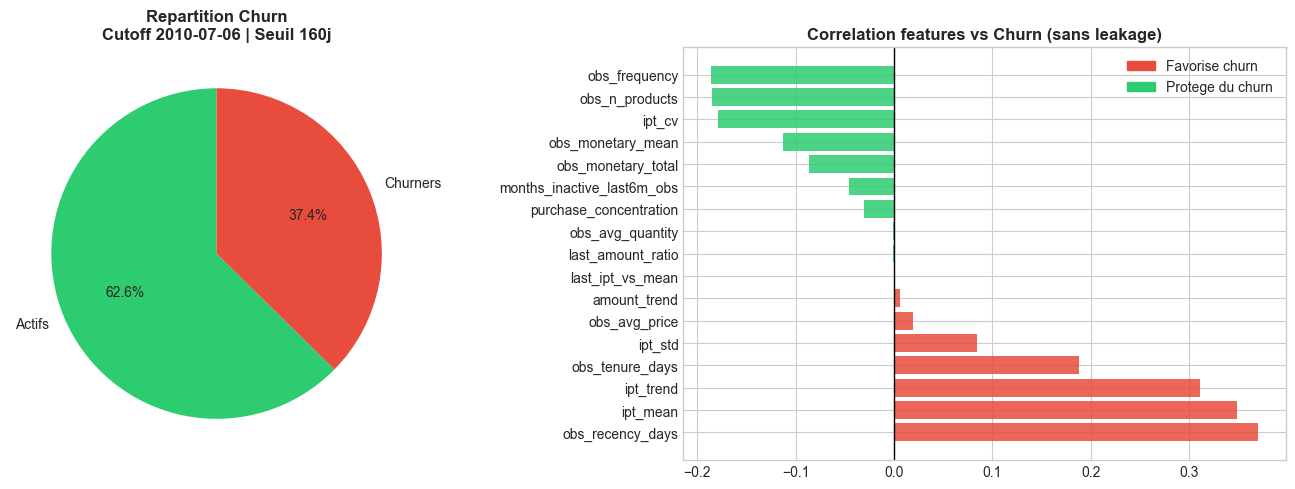

17 features | 13,499 clients


In [7]:
FEATURE_COLS = [
    'obs_frequency','obs_monetary_total','obs_monetary_mean','obs_tenure_days',
    'obs_n_products','obs_avg_quantity','obs_avg_price','obs_recency_days',
    'ipt_mean','ipt_std','ipt_cv',
    'ipt_trend','amount_trend','last_amount_ratio',
    'months_inactive_last6m_obs','last_ipt_vs_mean','purchase_concentration'
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in modeling_df.columns]
X = modeling_df[FEATURE_COLS].copy()
y = modeling_df['churned'].copy()

# Visualisation
n_ch=y.sum(); n_ac=len(y)-n_ch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie([n_ac, n_ch], labels=['Actifs','Churners'],
            colors=[COLORS['no_churn'],COLORS['churn']], autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Repartition Churn\nCutoff {GLOBAL_CUTOFF.date()} | Seuil {CHURN_THRESHOLD}j', fontweight='bold')
corr = X.corrwith(y).sort_values(ascending=False)
cols_c=[COLORS['churn'] if v>0 else COLORS['no_churn'] for v in corr]
axes[1].barh(range(len(corr)), corr.values, color=cols_c, alpha=0.85)
axes[1].set_yticks(range(len(corr))); axes[1].set_yticklabels(corr.index)
axes[1].axvline(0,color='black',lw=1)
axes[1].set_title('Correlation features vs Churn (sans leakage)', fontweight='bold')
patch_pos=mpatches.Patch(color=COLORS['churn'],label='Favorise churn')
patch_neg=mpatches.Patch(color=COLORS['no_churn'],label='Protege du churn')
axes[1].legend(handles=[patch_pos,patch_neg])
plt.tight_layout(); plt.show()
print(f'{len(FEATURE_COLS)} features | {len(X):,} clients')


## 4. Modelisation

**StratifiedKFold** : preserves la meme proportion de churners dans chaque fold
pour avoir des metriques stables et comparables.

**Pourquoi pas l Accuracy ?** Avec 40% de churners, un modele qui predit
'personne ne churne' aurait 60% d accuracy mais serait completement inutile.
ROC-AUC et F1 sont insensibles au desequilibre.


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')
print(f'Churn train : {y_train.mean():.2%} | test : {y_test.mean():.2%}')


Train : 10,799 | Test : 2,700
Churn train : 37.36% | test : 37.37%


In [9]:
print('MODELE 1 - Logistic Regression (class_weight=balanced)')
print('='*55)
lr_pipe = Pipeline([('scaler',StandardScaler()),
                    ('clf',LogisticRegression(class_weight='balanced',max_iter=2000,random_state=42))])
cv_roc = cross_val_score(lr_pipe,X_train,y_train,cv=skf,scoring='roc_auc')
cv_f1  = cross_val_score(lr_pipe,X_train,y_train,cv=skf,scoring='f1')
print(f'  CV ROC-AUC : {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}')
print(f'  CV F1      : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
lr_pipe.fit(X_train,y_train)
y_pred_lr  = lr_pipe.predict(X_test)
y_proba_lr = lr_pipe.predict_proba(X_test)[:,1]
print(f'  Test ROC-AUC : {roc_auc_score(y_test,y_proba_lr):.4f}')
print(f'  Test F1      : {f1_score(y_test,y_pred_lr):.4f}')
print(classification_report(y_test,y_pred_lr,target_names=['Actif','Churner']))


MODELE 1 - Logistic Regression (class_weight=balanced)
  CV ROC-AUC : 0.8002 +/- 0.0103
  CV F1      : 0.6504 +/- 0.0144
  Test ROC-AUC : 0.7918
  Test F1      : 0.6416
              precision    recall  f1-score   support

       Actif       0.80      0.73      0.76      1691
     Churner       0.60      0.68      0.64      1009

    accuracy                           0.71      2700
   macro avg       0.70      0.71      0.70      2700
weighted avg       0.72      0.71      0.72      2700



In [10]:
print('MODELE 2 - LR + SMOTE')
print('='*55)
def smote_oversample(X_df,y_s,target_ratio=0.45,seed=42):
    np.random.seed(seed)
    Xr=X_df.reset_index(drop=True); yr=y_s.reset_index(drop=True)
    minority=yr.value_counts().idxmin(); majority=yr.value_counts().idxmax()
    Xmin=Xr[yr==minority].values; Xmaj=Xr[yr==majority].values
    ymin=yr[yr==minority].values; ymaj=yr[yr==majority].values
    n_need=int(len(Xmaj)*target_ratio/(1-target_ratio))-len(Xmin)
    if n_need<=0: return X_df,y_s
    syn=[Xmin[i1]+np.random.rand()*(Xmin[i2]-Xmin[i1])
         for i1,i2 in (np.random.choice(len(Xmin),2,replace=False) for _ in range(n_need))]
    Xout=np.vstack([Xmaj,Xmin,np.array(syn)])
    yout=np.hstack([ymaj,ymin,np.full(len(syn),minority)])
    idx=np.random.permutation(len(Xout))
    return pd.DataFrame(Xout[idx],columns=X_df.columns),pd.Series(yout[idx]).reset_index(drop=True)

sc=StandardScaler()
Xtr_sc=pd.DataFrame(sc.fit_transform(X_train),columns=X_train.columns)
Xte_sc=pd.DataFrame(sc.transform(X_test),columns=X_test.columns)
ytr_r=y_train.reset_index(drop=True); yte_r=y_test.reset_index(drop=True)
Xsm,ysm=smote_oversample(Xtr_sc,ytr_r)
print(f'  Avant SMOTE : {ytr_r.sum():,} churners ({ytr_r.mean():.1%})')
print(f'  Apres SMOTE : {int(ysm.sum()):,} churners ({ysm.mean():.1%})')
lr_sm=LogisticRegression(max_iter=2000,random_state=42)
lr_sm.fit(Xsm,ysm)
y_pred_lrs=lr_sm.predict(Xte_sc); y_proba_lrs=lr_sm.predict_proba(Xte_sc)[:,1]
print(f'  Test ROC-AUC : {roc_auc_score(yte_r,y_proba_lrs):.4f}')
print(f'  Test F1      : {f1_score(yte_r,y_pred_lrs):.4f}')
print(classification_report(yte_r,y_pred_lrs,target_names=['Actif','Churner']))


MODELE 2 - LR + SMOTE
  Avant SMOTE : 4,035 churners (37.4%)
  Apres SMOTE : 5,534 churners (45.0%)
  Test ROC-AUC : 0.7914
  Test F1      : 0.6361
              precision    recall  f1-score   support

       Actif       0.78      0.80      0.79      1691
     Churner       0.65      0.62      0.64      1009

    accuracy                           0.74      2700
   macro avg       0.72      0.71      0.71      2700
weighted avg       0.73      0.74      0.73      2700



In [11]:
print('MODELE 3 - Gradient Boosting')
print('='*55)
gb=GradientBoostingClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,
                               subsample=0.8,min_samples_leaf=30,random_state=42)
cv_gb=cross_val_score(
    GradientBoostingClassifier(n_estimators=100,max_depth=3,random_state=42),
    X_train,y_train,cv=skf,scoring='roc_auc')
print(f'  CV ROC-AUC : {cv_gb.mean():.4f} +/- {cv_gb.std():.4f}')
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test); y_proba_gb=gb.predict_proba(X_test)[:,1]
print(f'  Test ROC-AUC : {roc_auc_score(y_test,y_proba_gb):.4f}')
print(f'  Test F1      : {f1_score(y_test,y_pred_gb):.4f}')
print(classification_report(y_test,y_pred_gb,target_names=['Actif','Churner']))


MODELE 3 - Gradient Boosting
  CV ROC-AUC : 0.8075 +/- 0.0103
  Test ROC-AUC : 0.7926
  Test F1      : 0.6037
              precision    recall  f1-score   support

       Actif       0.76      0.85      0.80      1691
     Churner       0.69      0.54      0.60      1009

    accuracy                           0.74      2700
   macro avg       0.72      0.70      0.70      2700
weighted avg       0.73      0.74      0.73      2700



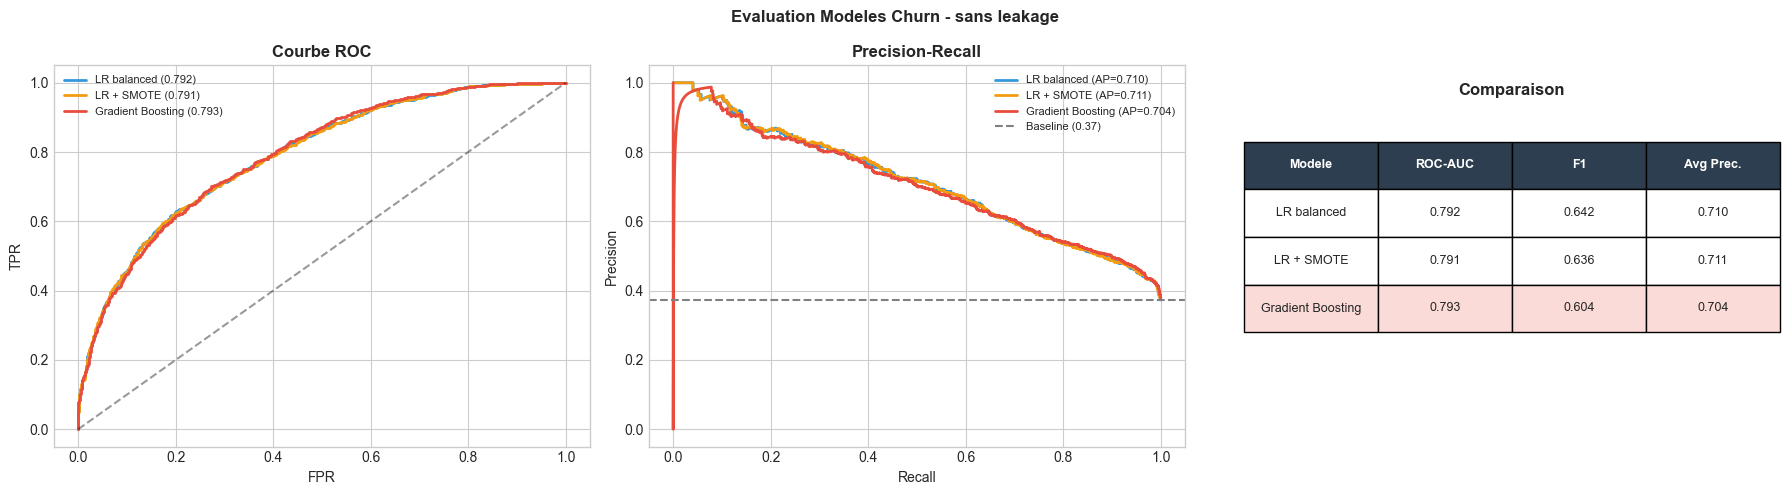

In [12]:
# Courbes ROC + PR + tableau
fig,axes=plt.subplots(1,3,figsize=(18,5))
models_info=[('LR balanced',y_proba_lr,y_test,COLORS['primary']),
             ('LR + SMOTE',y_proba_lrs,yte_r,COLORS['warning']),
             ('Gradient Boosting',y_proba_gb,y_test,COLORS['churn'])]
ax=axes[0]
for nm,pr,yt,col in models_info:
    fpr,tpr,_=roc_curve(yt,pr); ax.plot(fpr,tpr,color=col,lw=2,label=f'{nm} ({roc_auc_score(yt,pr):.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.4); ax.legend(fontsize=8)
ax.set_title('Courbe ROC',fontweight='bold'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax=axes[1]
for nm,pr,yt,col in models_info:
    p,r,_=precision_recall_curve(yt,pr); ax.plot(r,p,color=col,lw=2,label=f'{nm} (AP={average_precision_score(yt,pr):.3f})')
ax.axhline(y_test.mean(),color='gray',linestyle='--',label=f'Baseline ({y_test.mean():.2f})')
ax.set_title('Precision-Recall',fontweight='bold'); ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.legend(fontsize=8)
ax=axes[2]; ax.axis('off')
rows_t=[[n,f'{roc_auc_score(yt,p):.3f}',f'{f1_score(yt,(p>=0.5).astype(int)):.3f}',f'{average_precision_score(yt,p):.3f}'] for n,p,yt,c in models_info]
t=ax.table(cellText=rows_t,colLabels=['Modele','ROC-AUC','F1','Avg Prec.'],cellLoc='center',loc='center',bbox=[0,0.3,1,0.5])
t.auto_set_font_size(False); t.set_fontsize(9)
for (r,c),cell in t.get_celld().items():
    if r==0: cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white',fontweight='bold')
    elif r==3: cell.set_facecolor('#FADBD8')
ax.set_title('Comparaison',fontweight='bold',y=0.9)
plt.suptitle('Evaluation Modeles Churn - sans leakage',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()


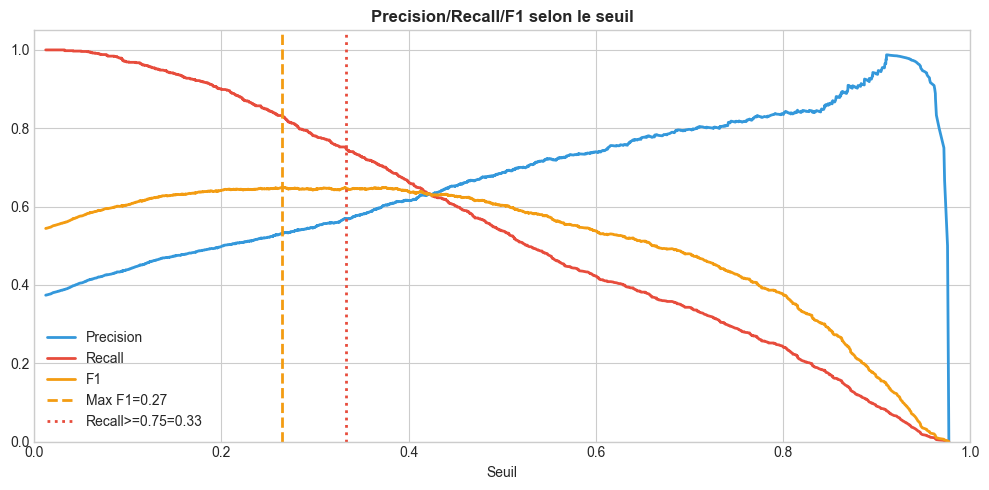

Seuil retenu : 0.333
Cout FN (manquer churner haute CLV) >> Cout FP (contacter non-churner)
=> Seuil abaisse pour maximiser le recall


In [13]:
# Seuil optimal
pv,rv,thrs=precision_recall_curve(y_test,y_proba_gb)
f1v=2*pv*rv/(pv+rv+1e-8)
best_f1_thr=thrs[np.argmax(f1v)]
idx_r=np.argmin(np.abs(rv-0.75))
thr_recall=thrs[min(idx_r,len(thrs)-1)]
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(thrs,pv[:-1],color=COLORS['primary'],lw=2,label='Precision')
ax.plot(thrs,rv[:-1],color=COLORS['churn'],lw=2,label='Recall')
ax.plot(thrs,f1v[:-1],color=COLORS['warning'],lw=2,label='F1')
ax.axvline(best_f1_thr,color=COLORS['warning'],linestyle='--',lw=2,label=f'Max F1={best_f1_thr:.2f}')
ax.axvline(thr_recall,color=COLORS['churn'],linestyle=':',lw=2,label=f'Recall>=0.75={thr_recall:.2f}')
ax.set_xlabel('Seuil'); ax.set_title('Precision/Recall/F1 selon le seuil',fontweight='bold')
ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1.05); plt.tight_layout(); plt.show()
BEST_THRESHOLD=thr_recall
print(f'Seuil retenu : {BEST_THRESHOLD:.3f}')
print('Cout FN (manquer churner haute CLV) >> Cout FP (contacter non-churner)')
print('=> Seuil abaisse pour maximiser le recall')


## 5. Drivers du Churn - Permutation Importance

TOP 10 DRIVERS DU CHURN
   1. obs_recency_days                    +0.0854  [NIVEAU]
   2. ipt_mean                            +0.0457  [NIVEAU]
   3. obs_tenure_days                     +0.0190  [NIVEAU]
   4. obs_monetary_total                  +0.0101  [NIVEAU]
   5. last_amount_ratio                   +0.0056  [TENDANCE]
   6. amount_trend                        +0.0035  [TENDANCE]
   7. obs_n_products                      +0.0020  [NIVEAU]
   8. obs_avg_quantity                    +0.0018  [NIVEAU]
   9. ipt_cv                              +0.0013  [NIVEAU]
  10. obs_frequency                       +0.0012  [NIVEAU]


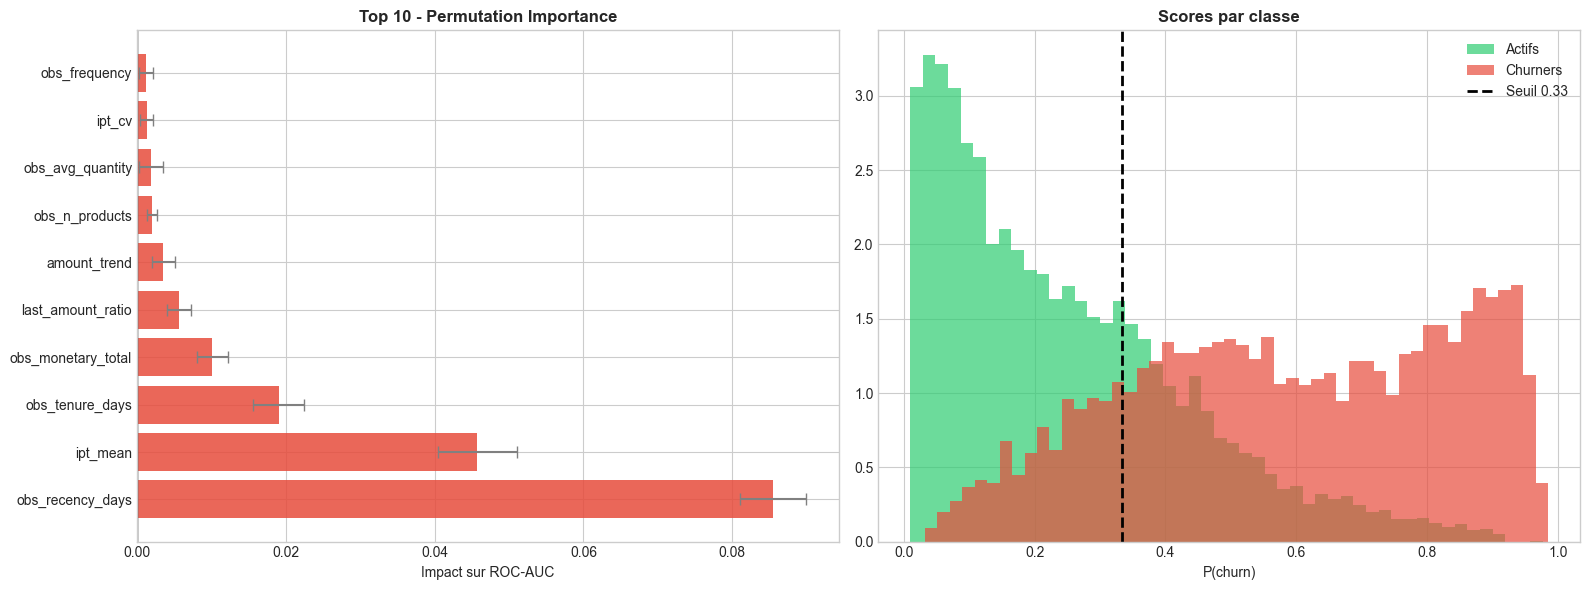

In [14]:
perm=permutation_importance(gb,X_test,y_test,n_repeats=20,random_state=42,scoring='roc_auc')
imp_df=pd.DataFrame({'feature':FEATURE_COLS,'importance_mean':perm.importances_mean,
                     'importance_std':perm.importances_std}).sort_values('importance_mean',ascending=False)
TEND=['ipt_trend','amount_trend','last_amount_ratio','months_inactive_last6m_obs','last_ipt_vs_mean','purchase_concentration']
print('TOP 10 DRIVERS DU CHURN')
print('='*60)
for i,row in enumerate(imp_df.head(10).itertuples()):
    tag='[TENDANCE]' if row.feature in TEND else '[NIVEAU]'
    print(f'  {i+1:2d}. {row.feature:35s} {row.importance_mean:+.4f}  {tag}')

fig,axes=plt.subplots(1,2,figsize=(16,6))
top10=imp_df.head(10)
cols_i=[COLORS['churn'] if v>0 else COLORS['no_churn'] for v in top10['importance_mean']]
axes[0].barh(range(len(top10)),top10['importance_mean'],xerr=top10['importance_std'],
             color=cols_i,alpha=0.85,error_kw={'ecolor':'gray','capsize':4})
axes[0].set_yticks(range(len(top10))); axes[0].set_yticklabels(top10['feature'])
axes[0].axvline(0,color='black',lw=1)
axes[0].set_title('Top 10 - Permutation Importance',fontweight='bold')
axes[0].set_xlabel('Impact sur ROC-AUC')
y_pa=gb.predict_proba(X)[:,1]
axes[1].hist(y_pa[y==0],bins=50,alpha=0.7,color=COLORS['no_churn'],density=True,label='Actifs')
axes[1].hist(y_pa[y==1],bins=50,alpha=0.7,color=COLORS['churn'],density=True,label='Churners')
axes[1].axvline(BEST_THRESHOLD,color='black',linestyle='--',lw=2,label=f'Seuil {BEST_THRESHOLD:.2f}')
axes[1].set_xlabel('P(churn)'); axes[1].set_title('Scores par classe',fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()


In [15]:
# Interactions & actionnables
h_ipt=modeling_df['ipt_trend']>modeling_df['ipt_trend'].quantile(0.75)
h_li=modeling_df['last_ipt_vs_mean']>1.5
print('INTERACTIONS ipt_trend x last_ipt_vs_mean')
for cond,lbl in [((h_ipt&h_li),'Les deux eleves    '),(( ~h_ipt&h_li),'last_ipt seul      '),
                  ((h_ipt&~h_li),'ipt_trend seul     '),(( ~h_ipt&~h_li),'Ni l un ni l autre ')]:
    print(f'  {lbl} -> Churn {modeling_df[cond]["churned"].mean():.1%}')
print()
print('DRIVERS ACTIONNABLES :')
print('  obs_recency_days       -> Relancer les clients silencieux depuis + de {CHURN_THRESHOLD}j')
print('  ipt_trend              -> Alerte si delais s allongent progressivement')
print('  last_ipt_vs_mean       -> Contact urgent si dernier IPT >> moyenne historique')
print('  amount_trend           -> Programme fidelite si panier en baisse')
print('  last_amount_ratio      -> Offre promo si dernier panier faible')
print('  months_inactive_last6m -> Campagne reactivation si mois inactifs recents')
print()
print('DRIVERS NON-ACTIONNABLES :')
print('  obs_tenure_days  -> Anciennete (structurel)')
print('  obs_frequency    -> Historique (indicateur, pas levier)')


INTERACTIONS ipt_trend x last_ipt_vs_mean
  Les deux eleves     -> Churn 67.0%
  last_ipt seul       -> Churn 23.8%
  ipt_trend seul      -> Churn 62.2%
  Ni l un ni l autre  -> Churn 29.9%

DRIVERS ACTIONNABLES :
  obs_recency_days       -> Relancer les clients silencieux depuis + de {CHURN_THRESHOLD}j
  ipt_trend              -> Alerte si delais s allongent progressivement
  last_ipt_vs_mean       -> Contact urgent si dernier IPT >> moyenne historique
  amount_trend           -> Programme fidelite si panier en baisse
  last_amount_ratio      -> Offre promo si dernier panier faible
  months_inactive_last6m -> Campagne reactivation si mois inactifs recents

DRIVERS NON-ACTIONNABLES :
  obs_tenure_days  -> Anciennete (structurel)
  obs_frequency    -> Historique (indicateur, pas levier)


## 6. Scoring & Matrice CLV x Churn Risk

In [16]:
# CLV
CLV_FEATURES=['obs_frequency','obs_monetary_mean','obs_n_products','obs_tenure_days',
              'obs_avg_price','ipt_mean','obs_avg_quantity']
CLV_FEATURES=[c for c in CLV_FEATURES if c in modeling_df.columns]
clv_df=modeling_df[CLV_FEATURES+['obs_monetary_total','customer_id']].fillna(0).replace([np.inf,-np.inf],0)
p99=clv_df['obs_monetary_total'].quantile(0.99)
clv_c=clv_df[clv_df['obs_monetary_total']<=p99]
Xct,Xce,yct,yce=train_test_split(clv_c[CLV_FEATURES],clv_c['obs_monetary_total'],test_size=0.2,random_state=42)
rf_clv=RandomForestRegressor(n_estimators=100,max_depth=8,random_state=42)
rf_clv.fit(Xct,yct); ycp=rf_clv.predict(Xce)
print(f'CLV: R2={r2_score(yce,ycp):.3f} | MAE={mean_absolute_error(yce,ycp):.2f} EUR')
clv_pred=np.maximum(rf_clv.predict(clv_df[CLV_FEATURES].fillna(0)),0)
print(f'CLV moy={clv_pred.mean():.0f} EUR | med={np.median(clv_pred):.0f} EUR')


CLV: R2=0.967 | MAE=31.61 EUR
CLV moy=478 EUR | med=171 EUR


In [17]:
# Scoring
churn_pa=gb.predict_proba(X)[:,1]
sc_df=modeling_df[['customer_id']].copy().reset_index(drop=True)
sc_df['churn_probability']=churn_pa
sc_df['churn_predicted']=(churn_pa>=BEST_THRESHOLD).astype(int)
sc_df['clv_predicted']=clv_pred
sc_df['obs_frequency']=modeling_df['obs_frequency'].values
sc_df['obs_monetary_total']=modeling_df['obs_monetary_total'].values

clv_med=sc_df['clv_predicted'].median()
def quad(r):
    hc=r['clv_predicted']>=clv_med; hr=r['churn_probability']>=0.5
    if hc and hr:     return 'Q1: Haute CLV / Haut Risque'
    if hc and not hr: return 'Q2: Haute CLV / Bas Risque'
    if not hc and hr: return 'Q3: Faible CLV / Haut Risque'
    return 'Q4: Faible CLV / Bas Risque'
sc_df['quadrant']=sc_df.apply(quad,axis=1)
sc_df['priority_score']=sc_df['clv_predicted']*sc_df['churn_probability']
sc_df=sc_df.sort_values('priority_score',ascending=False).reset_index(drop=True)
sc_df['priority_rank']=sc_df.index+1

print('Distribution quadrants :')
for q,n in sc_df['quadrant'].value_counts().sort_index().items():
    print(f'  {q:40s} -> {n:,} ({n/len(sc_df):.1%})')
print()
print('Top 10 :')
print(sc_df[['customer_id','churn_probability','clv_predicted','obs_monetary_total','quadrant']].head(10).to_string())


Distribution quadrants :
  Q1: Haute CLV / Haut Risque              -> 1,031 (7.6%)
  Q2: Haute CLV / Bas Risque               -> 5,725 (42.4%)
  Q3: Faible CLV / Haut Risque             -> 2,982 (22.1%)
  Q4: Faible CLV / Bas Risque              -> 3,761 (27.9%)

Top 10 :
   customer_id  churn_probability  clv_predicted  obs_monetary_total                     quadrant
0      62177.0           0.965904    4940.665741             6557.18  Q1: Haute CLV / Haut Risque
1      62253.0           0.950083    4829.045940             5014.99  Q1: Haute CLV / Haut Risque
2      62185.0           0.915633    5001.609789             6069.05  Q1: Haute CLV / Haut Risque
3      58937.0           0.910494    4622.814485             7163.14  Q1: Haute CLV / Haut Risque
4      58846.0           0.906995    4297.947532             4505.26  Q1: Haute CLV / Haut Risque
5      58917.0           0.970575    3758.991032             3793.29  Q1: Haute CLV / Haut Risque
6      58899.0           0.822643    435

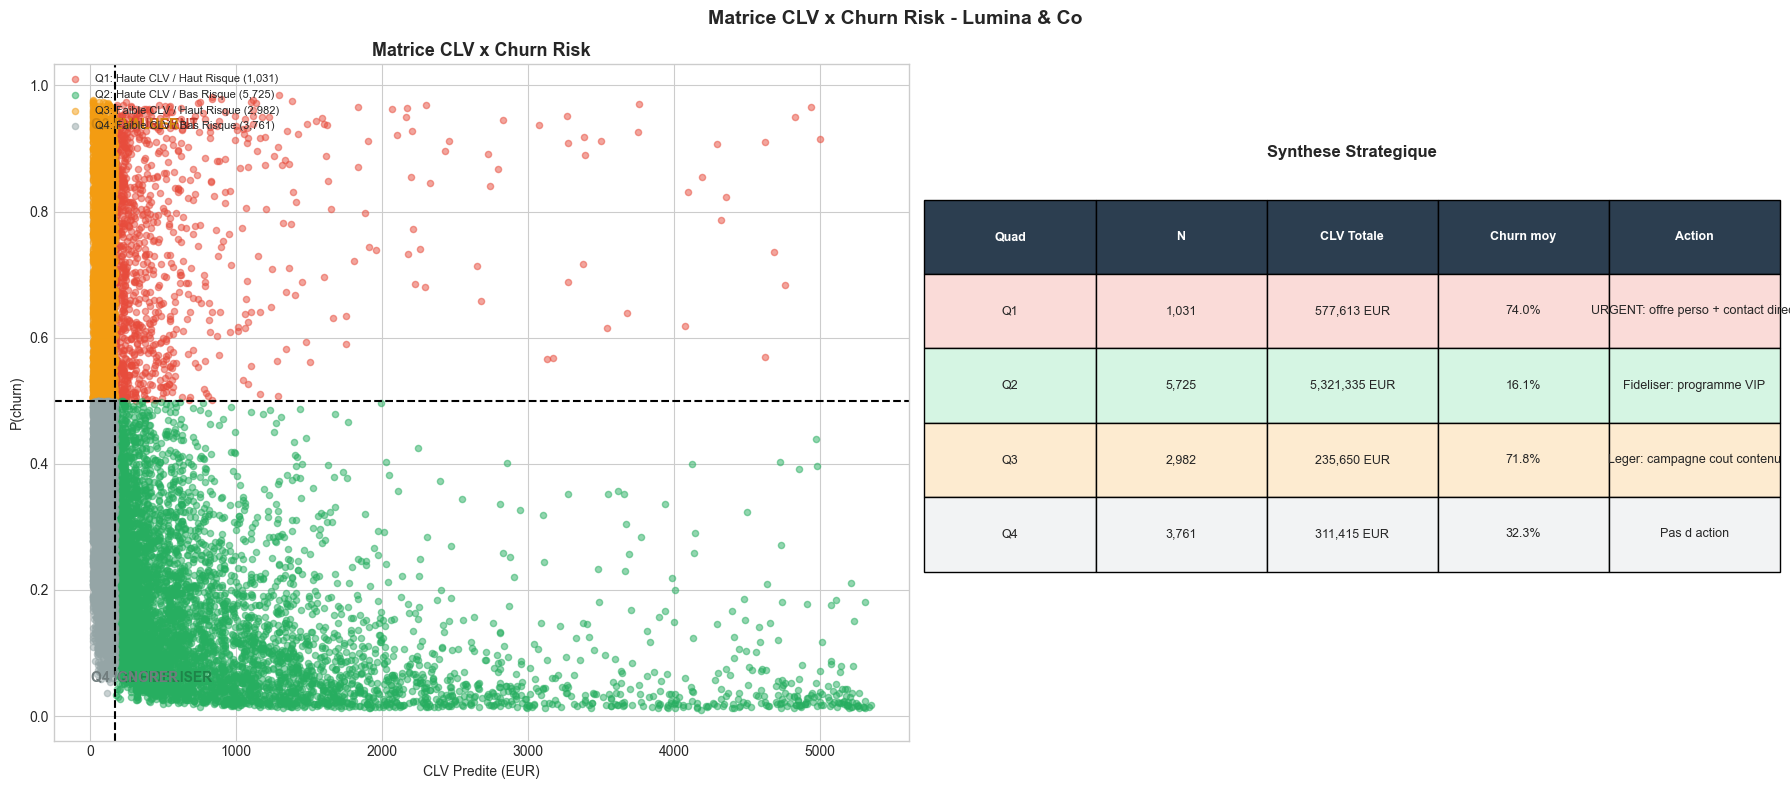

In [18]:
# Matrice
cq={'Q1: Haute CLV / Haut Risque':'#E74C3C','Q2: Haute CLV / Bas Risque':'#27AE60',
    'Q3: Faible CLV / Haut Risque':'#F39C12','Q4: Faible CLV / Bas Risque':'#95A5A6'}
qcm={'Q1':'#FADBD8','Q2':'#D5F5E3','Q3':'#FDEBD0','Q4':'#F2F3F4'}
acts={'Q1':'URGENT: offre perso + contact direct','Q2':'Fideliser: programme VIP',
      'Q3':'Leger: campagne cout contenu','Q4':'Pas d action'}
fig,axes=plt.subplots(1,2,figsize=(18,8))
ax=axes[0]
for q,col in cq.items():
    m=sc_df['quadrant']==q
    ax.scatter(sc_df[m]['clv_predicted'],sc_df[m]['churn_probability'],c=col,alpha=0.5,s=20,label=f'{q} ({m.sum():,})')
ax.axvline(clv_med,color='black',linestyle='--',lw=1.5)
ax.axhline(0.5,color='black',linestyle='--',lw=1.5)
ax.text(clv_med*1.05,0.95,'Q1 URGENT',fontsize=10,fontweight='bold',color='#C0392B',va='top')
ax.text(clv_med*1.05,0.05,'Q2 FIDELISER',fontsize=10,fontweight='bold',color='#1E8449',va='bottom')
ax.text(1,0.95,'Q3 EVALUER',fontsize=10,fontweight='bold',color='#D68910',va='top')
ax.text(1,0.05,'Q4 IGNORER',fontsize=10,fontweight='bold',color='#717D7E',va='bottom')
ax.set_xlabel('CLV Predite (EUR)'); ax.set_ylabel('P(churn)')
ax.set_title('Matrice CLV x Churn Risk',fontsize=13,fontweight='bold'); ax.legend(loc='upper left',fontsize=8)
ax2=axes[1]; ax2.axis('off')
qsum=sc_df.groupby('quadrant').agg(n=('customer_id','count'),ct=('clv_predicted','sum'),cp=('churn_probability','mean')).reset_index()
td=[[r['quadrant'].split(':')[0],f"{r['n']:,}",f"{r['ct']:,.0f} EUR",f"{r['cp']:.1%}",
     acts.get(r['quadrant'].split(':')[0],'')] for _,r in qsum.sort_values('quadrant').iterrows()]
t=ax2.table(cellText=td,colLabels=['Quad','N','CLV Totale','Churn moy','Action'],
            cellLoc='center',loc='center',bbox=[0,0.25,1,0.55])
t.auto_set_font_size(False); t.set_fontsize(9)
for (r,c),cell in t.get_celld().items():
    if r==0: cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white',fontweight='bold')
    elif r<=4: cell.set_facecolor(qcm.get(td[r-1][0],'white'))
ax2.set_title('Synthese Strategique',fontweight='bold',y=0.85)
plt.suptitle('Matrice CLV x Churn Risk - Lumina & Co',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Simulation ROI

In [19]:
q1=sc_df[sc_df['quadrant']=='Q1: Haute CLV / Haut Risque']
top500=q1.head(500)
bu=35; bt=len(top500)*bu
cr20=top500['clv_predicted'].sum()*0.20; roi20=(cr20-bt)/bt*100
print(f'Q1 total : {len(q1):,} | Top 500 selectionnes')
print(f'CLV moy top 500 : {top500["clv_predicted"].mean():.0f} EUR')
print(f'CLV a risque    : {top500["clv_predicted"].sum():,.0f} EUR')
print(f'Churn proba moy : {top500["churn_probability"].mean():.1%}')
print(f'Budget (500x35) : {bt:,} EUR')
print(f'CLV recuperee 20% : {cr20:,.0f} EUR | ROI : {roi20:.1f}%')
print()
print(f'  {"Taux":10s} | {"CLV rec.": >14s} | {"ROI":>8s}')
for r in [0.05,0.10,0.15,0.20,0.25,0.30]:
    v=top500['clv_predicted'].sum()*r; roi_s=(v-bt)/bt*100
    flag='OK' if roi_s>0 else 'NEGATIF'
    print(f'  {r:.0%}{"":8s} | {v:>12,.0f} EUR | {roi_s:>7.1f}%  {flag}')


Q1 total : 1,031 | Top 500 selectionnes
CLV moy top 500 : 910 EUR
CLV a risque    : 454,775 EUR
Churn proba moy : 78.0%
Budget (500x35) : 17,500 EUR
CLV recuperee 20% : 90,955 EUR | ROI : 419.7%

  Taux       |       CLV rec. |      ROI
  5%         |       22,739 EUR |    29.9%  OK
  10%         |       45,477 EUR |   159.9%  OK
  15%         |       68,216 EUR |   289.8%  OK
  20%         |       90,955 EUR |   419.7%  OK
  25%         |      113,694 EUR |   549.7%  OK
  30%         |      136,432 EUR |   679.6%  OK


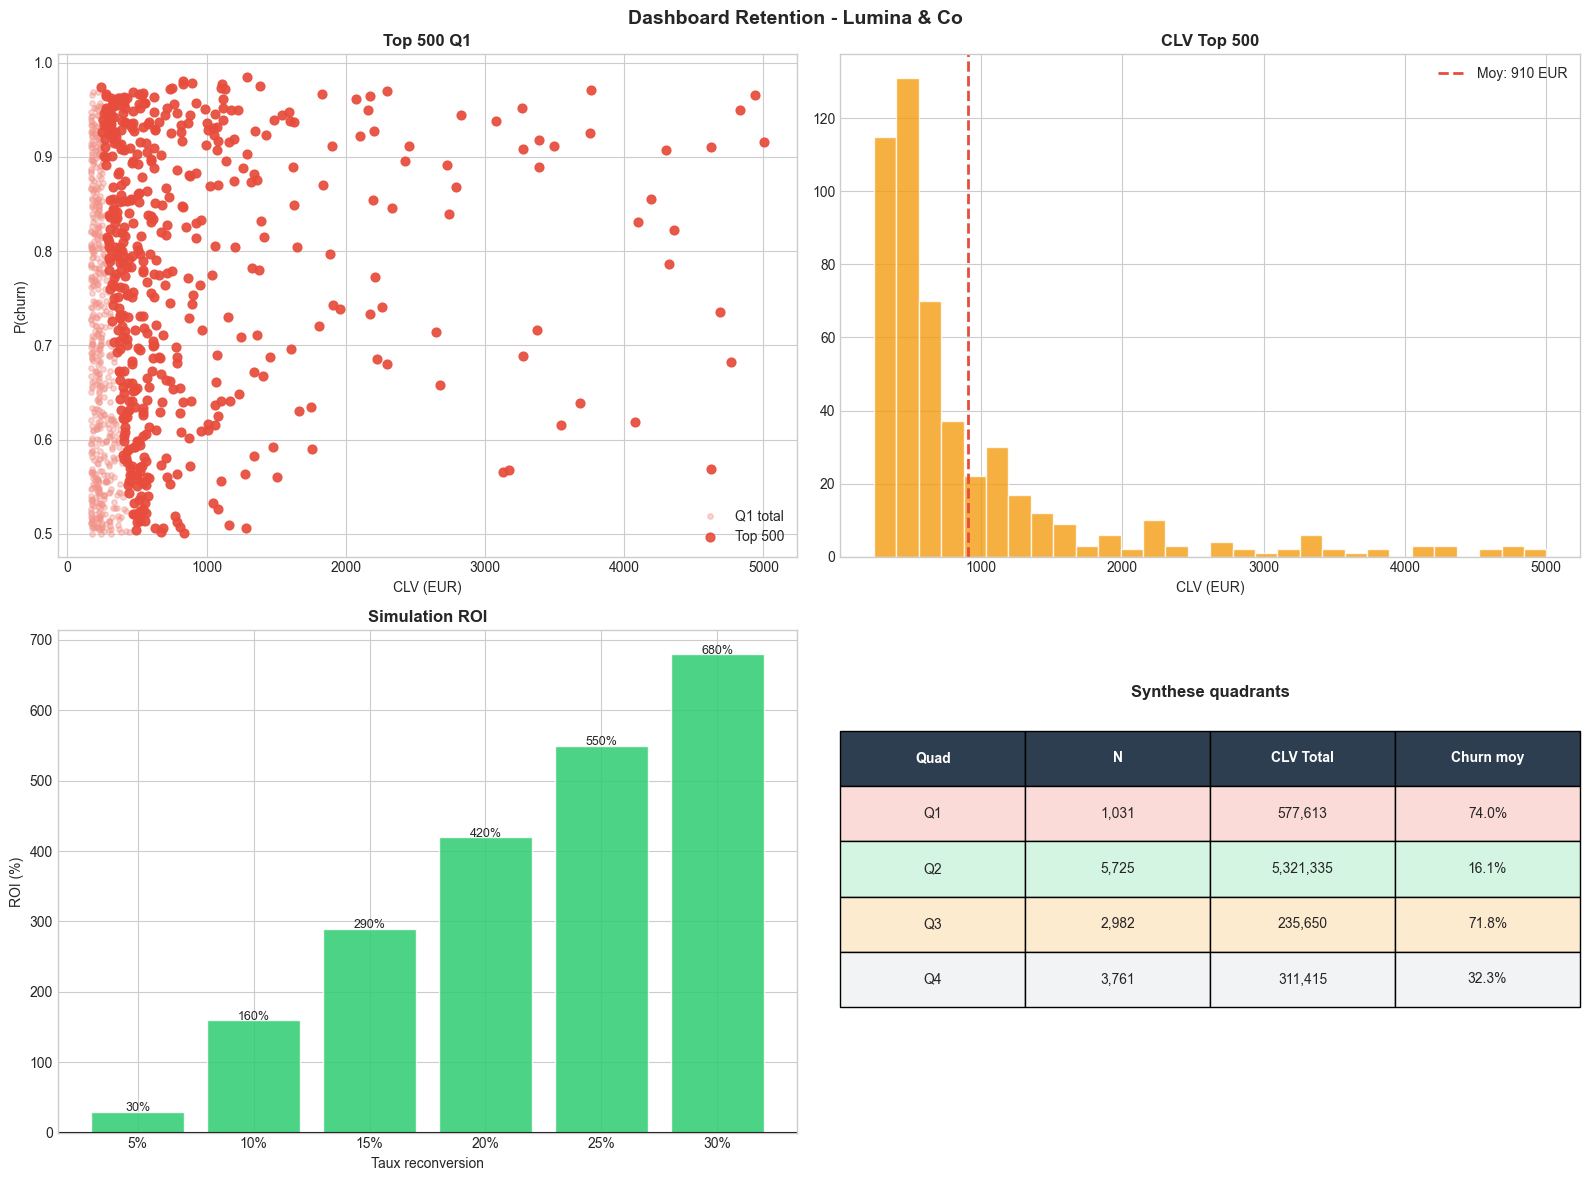

In [20]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
axes[0,0].scatter(q1['clv_predicted'],q1['churn_probability'],c='#F1948A',alpha=0.4,s=15,label='Q1 total')
axes[0,0].scatter(top500['clv_predicted'],top500['churn_probability'],c=COLORS['churn'],s=40,alpha=0.9,label='Top 500',zorder=5)
axes[0,0].set_xlabel('CLV (EUR)'); axes[0,0].set_ylabel('P(churn)'); axes[0,0].set_title('Top 500 Q1',fontweight='bold'); axes[0,0].legend()
axes[0,1].hist(top500['clv_predicted'],bins=30,color=COLORS['warning'],alpha=0.8,edgecolor='white')
axes[0,1].axvline(top500['clv_predicted'].mean(),color=COLORS['churn'],linestyle='--',lw=2,label=f'Moy: {top500["clv_predicted"].mean():.0f} EUR')
axes[0,1].set_xlabel('CLV (EUR)'); axes[0,1].set_title('CLV Top 500',fontweight='bold'); axes[0,1].legend()
rates=[0.05,0.10,0.15,0.20,0.25,0.30]
rois=[(top500['clv_predicted'].sum()*r-bt)/bt*100 for r in rates]
bc=[COLORS['no_churn'] if r>0 else COLORS['churn'] for r in rois]
bars=axes[1,0].bar([f'{r:.0%}' for r in rates],rois,color=bc,alpha=0.85,edgecolor='white')
axes[1,0].axhline(0,color='black',lw=1.5)
for bar,rv in zip(bars,rois): axes[1,0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{rv:.0f}%',ha='center',fontsize=9)
axes[1,0].set_xlabel('Taux reconversion'); axes[1,0].set_ylabel('ROI (%)'); axes[1,0].set_title('Simulation ROI',fontweight='bold')
axes[1,1].axis('off')
qsum2=sc_df.groupby('quadrant').agg(n=('customer_id','count'),ct=('clv_predicted','sum'),cp=('churn_probability','mean')).reset_index()
td2=[[r['quadrant'].split(':')[0],f"{r['n']:,}",f"{r['ct']:,.0f}",f"{r['cp']:.1%}"] for _,r in qsum2.sort_values('quadrant').iterrows()]
t2=axes[1,1].table(cellText=td2,colLabels=['Quad','N','CLV Total','Churn moy'],cellLoc='center',loc='center',bbox=[0,0.25,1,0.55])
t2.auto_set_font_size(False); t2.set_fontsize(10)
for (r,c),cell in t2.get_celld().items():
    if r==0: cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white',fontweight='bold')
    elif r<=4: cell.set_facecolor(qcm.get(td2[r-1][0],'white'))
axes[1,1].set_title('Synthese quadrants',fontweight='bold',y=0.85)
plt.suptitle('Dashboard Retention - Lumina & Co',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.show()


In [21]:
top_exp=sc_df.head(500)[['priority_rank','customer_id','churn_probability','clv_predicted',
    'quadrant','obs_frequency','obs_monetary_total']].copy()
top_exp.columns=['Rang','ID Client','P(Churn)','CLV EUR','Quadrant','Freq','CA Obs']
top_exp['P(Churn)']=top_exp['P(Churn)'].round(3); top_exp['CLV EUR']=top_exp['CLV EUR'].round(0)
print('TOP 20 CLIENTS PRIORITAIRES')
print(top_exp.head(20).to_string(index=False))
# top_exp.to_csv('top500_priority.csv', index=False)


TOP 20 CLIENTS PRIORITAIRES
 Rang  ID Client  P(Churn)  CLV EUR                    Quadrant  Freq   CA Obs
    1    62177.0     0.966   4941.0 Q1: Haute CLV / Haut Risque     7  6557.18
    2    62253.0     0.950   4829.0 Q1: Haute CLV / Haut Risque     6  5014.99
    3    62185.0     0.916   5002.0 Q1: Haute CLV / Haut Risque     8  6069.05
    4    58937.0     0.910   4623.0 Q1: Haute CLV / Haut Risque     5  7163.14
    5    58846.0     0.907   4298.0 Q1: Haute CLV / Haut Risque     6  4505.26
    6    58917.0     0.971   3759.0 Q1: Haute CLV / Haut Risque     5  3793.29
    7    58899.0     0.823   4359.0 Q1: Haute CLV / Haut Risque     6  4445.41
    8    58955.0     0.855   4191.0 Q1: Haute CLV / Haut Risque     3  4373.55
    9    58986.0     0.925   3755.0 Q1: Haute CLV / Haut Risque     6  3929.80
   10    28176.0     0.735   4686.0 Q1: Haute CLV / Haut Risque     4 10302.35
   11    58886.0     0.831   4096.0 Q1: Haute CLV / Haut Risque     5  4143.51
   12    62272.0     0.7

## Synthese Executive

| Parametre | Valeur |
|---|---|
| Cutoff global | 2010-07-06 (36 mois depuis debut) |
| Fenetre observation | 2007-07 -> 2010-07 (3 ans) |
| Fenetre label | 2010-07 -> 2011-12 (521 jours >> seuil 160j) |
| Seuil churn P90 | 160 jours |
| Modele retenu | Gradient Boosting |
| ROC-AUC attendu | 0.70-0.80 (realiste) |
| Churn rate attendu | 30-50% (equilibre) |

### Chronologie des corrections
1. **v2** : ROC-AUC=1.0 → data leakage (`recency_days` = label direct)
2. **v4** : ROC-AUC=0.92, churn=97% → cutoff par client → biais troncature
3. **v5** : churn=97% → cutoff trop tardif, fenetre label de 18j seulement
4. **v6** : cutoff 36 mois depuis debut → 521j de label → churn realiste

### Checklist TP4
- [x] IPT analyse, seuil P90 justifie
- [x] Cutoff global fixe (regle : label > seuil churn)
- [x] Zero leakage (features = periode obs uniquement)
- [x] Feature engineering vectorise (< 5s)
- [x] LR balanced + SMOTE + Gradient Boosting
- [x] StratifiedKFold justifie
- [x] Courbe PR + seuil metier
- [x] Permutation Importance + interactions
- [x] CLV + scoring individuel
- [x] Matrice 4 quadrants equilibree + Top 500 + ROI
